# ASR Metrics Analysis

Let's take a look a the following metrics we've compiled from the three models to compare performance.

Models:

- openai/whisper-small
- openai/whisper-large-v3
- ibm-granite/granite-4.0-1b-speech

Metrics from the jiwer library<sup>[1](#myfootnote1)</sup>:

- Word Error Rate (WER): the total number of substitutions, deletions, and insertions divided by the number of words in the hypothesis text.
- Character Error Rate (CER): the same measurement as WER but except the accuracy is done at at the character.
- Match Error Rate (MER): This measure "calculates the proportion of word-level errors relative to the total number of correct matches plus the number of errors. The lower the value, the better the performance of the ASR system, with an error rate of 0 indicating a perfect score."
- Word Information Lost (WIL): A computation of the information lost in the hypothesis text compared to the ground-truth.
- Word Information Preserved (WIP): The inverse of WIL, or the amount of information from the ground-truth that is preserved in the hypothesis text. 

<sup>[1](#myfootnote1)</sup> Definitions are adapted or quoted from <b>Sense Lab: Speech to text evaluation</b> available at https://sensein.group/senselab/senselab/audio/tasks/speech_to_text_evaluation



In [1]:
from pathlib import Path, PosixPath
import json
from typing import List, Dict
import pandas as pd

data_dir = Path('.').parent / "reports"

def get_reports(dir: Path) -> List[PosixPath]:
    return [f for f in dir.iterdir() if f.is_file() and f.suffix == ".json"]

def load_reports(file_names: str) -> Dict:
    reports = get_reports(data_dir)
    return {
        f.name.replace('sample_file_', '').replace('_metrics.json', ''): json.loads(open(f).read())
        for f in reports
    }

reports = load_reports(data_dir)
for key in reports.keys():
    print(key)

4_ibm-granite-granite-4-0-1b-speech
5_openai-whisper-large-v3
2_openai-whisper-large-v3
5_openai-whisper-small
1_ibm-granite-granite-4-0-1b-speech
4_openai-whisper-large-v3
3_openai-whisper-large-v3
3_ibm-granite-granite-4-0-1b-speech
4_openai-whisper-small
2_ibm-granite-granite-4-0-1b-speech
2_openai-whisper-small
1_openai-whisper-small
1_openai-whisper-large-v3
5_ibm-granite-granite-4-0-1b-speech
3_openai-whisper-small


In [2]:
def reshape_data(reports: Dict):
    reorganized_data = []
    for name, data in reports.items():
        model = data.get('model')
        file = f"file_{name.split('_')[0]}"
        data.update({"file": file})
        reorganized_data.append(data)
    return reorganized_data

data = reshape_data(reports)

df = pd.DataFrame(data)
df = df.set_index(['file', 'model'])
df = df.sort_index()
df.head(15)

wer       cer       mer  \
file   model                                                             
file_1 ibm-granite/granite-4.0-1b-speech  1.000000  0.862745  1.000000   
       openai/whisper-large-v3            0.421053  0.343137  0.421053   
       openai/whisper-small               0.421053  0.343137  0.421053   
file_2 ibm-granite/granite-4.0-1b-speech  1.727273  0.859375  1.000000   
       openai/whisper-large-v3            0.181818  0.031250  0.181818   
       openai/whisper-small               0.272727  0.078125  0.272727   
file_3 ibm-granite/granite-4.0-1b-speech  1.538462  0.915493  1.000000   
       openai/whisper-large-v3            0.846154  0.183099  0.687500   
       openai/whisper-small               0.615385  0.126761  0.571429   
file_4 ibm-granite/granite-4.0-1b-speech  0.980392  0.766129  0.980392   
       openai/whisper-large-v3            0.098039  0.036290  0.098039   
       openai/whisper-small               0.117647  0.044355  0.117647   
file_5 ibm-granite/granite-4.0-1b-speech  1.818182  1.035714  1.000000   
       openai/whisper-large-v3            0.090909  0.089286  0.090909   
       openai/whisper-small               0.090909  0.125000  0.090909   

                                               wil       wip  
file   model                                                  
file_1 ibm-granite/granite-4.0-1b-speech  1.000000  0.000000  
       openai/whisper-large-v3            0.469298  0.530702  
       openai/whisper-small               0.469298  0.530702  
file_2 ibm-granite/granite-4.0-1b-speech  1.000000  0.000000  
       openai/whisper-large-v3            0.330579  0.669421  
       openai/whisper-small               0.471074  0.528926  
file_3 ibm-granite/granite-4.0-1b-speech  1.000000  0.000000  
       openai/whisper-large-v3            0.879808  0.120192  
       openai/whisper-small               0.802198  0.197802  
file_4 ibm-granite/granite-4.0-1b-speech  0.999020  0.000980  
       openai/whisper-large-v3            0.186467  0.813533  
       openai/whisper-small               0.221453  0.778547  
file_5 ibm-granite/granite-4.0-1b-speech  1.000000  0.000000  
       openai/whisper-large-v3            0.173554  0.826446  
       openai/whisper-small               0.173554  0.826446

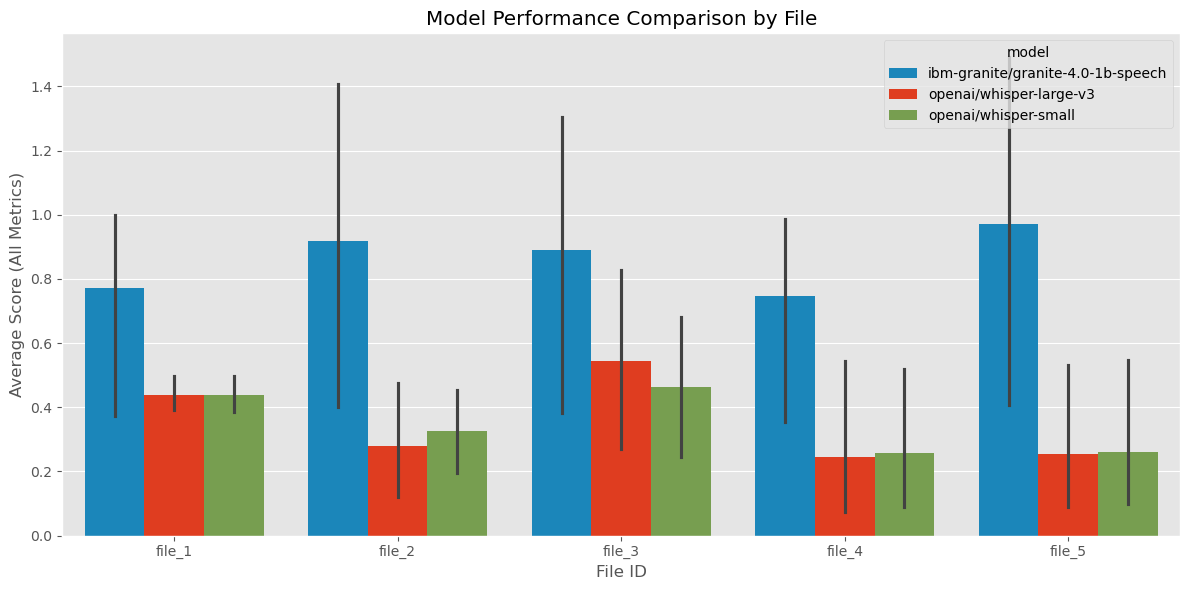

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

df.reset_index(inplace=True)
df_data = df.melt(id_vars=['file', 'model'], var_name='Metric', value_name='Score')

plt.style.use('ggplot') 
model_colors = {
    'ibm-granite/granite-4.0-1b-speech': '#008FD5',
    'openai/whisper-large-v3': '#FF2700',   
    'openai/whisper-small': '#77AB43' 
}

plt.figure(figsize=(12, 6))

sns.barplot(data=df_data, x='file', y='Score', hue='model', palette=model_colors)

plt.title('Model Performance Comparison by File')
plt.ylabel('Average Score (All Metrics)')
plt.xlabel('File ID')
plt.tight_layout()
plt.show()


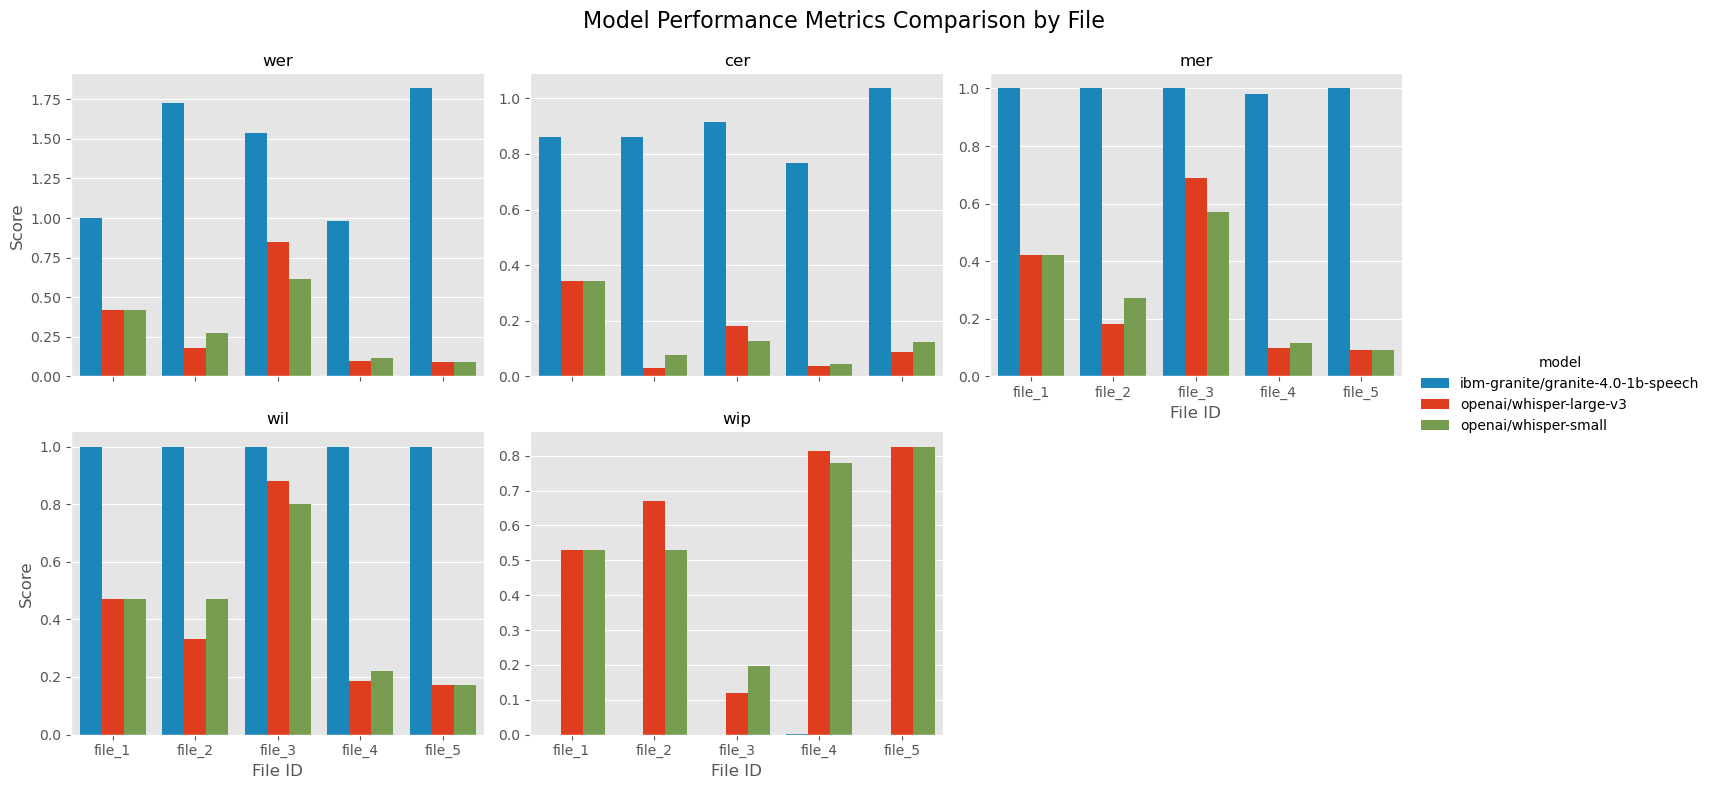

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt


df_data = df.melt(id_vars=['file', 'model'], var_name='Metric', value_name='Score')

g = sns.catplot(
    data=df_data, 
    x='file', 
    y='Score', 
    hue='model', 
    col='Metric', 
    kind='bar',
    palette=model_colors,
    height=4, 
    aspect=1.2,
    col_wrap=3,
    sharey=False # Set to False if metrics have very different scales (e.g. 0-1 vs 0-100)
)


g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Model Performance Metrics Comparison by File', fontsize=16)
g.set_axis_labels("File ID", "Score")
g.set_titles("{col_name}")

plt.show()


# Discussion

With these metrics, lower is better in every category except wip (word information preserved). We can see that both whisper models outperform the granite model. The large-v3 and small whisper models are comparable, though the large-v3 in wer (word error rate), is most performant on all transcriptions apart from the third file.

For this reason, I think openai/whisper-large-v3 is the model that performs best among the three models to use in the application. Further manual testing with human users should confirm this selection.